# 01 Labels and Time EDA

Goal:
- analyze the distribution of transaction labels,
- compare known and unknown labels,
- inspect how labels change across time steps,
- quantify class imbalance in the supervised subset,
- motivate a chronological validation strategy for modeling.

## Setup

Import the plotting and data analysis libraries, define paths to the raw dataset files, and prepare output directories for summary tables and figures.

In [148]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("../dataset")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

FEATURES_PATH = DATA_DIR / "elliptic_txs_features.csv"
CLASSES_PATH = DATA_DIR / "elliptic_txs_classes.csv"

## Source files

Confirm that the two required source files exist. This notebook uses the features file only for `txId` and `time_step`, and the classes file for labels.

In [149]:
for path in [FEATURES_PATH, CLASSES_PATH]:
    print(path.name, path.exists(), f"{path.stat().st_size / 1024 ** 2:.2f} MB")

elliptic_txs_features.csv True 657.73 MB
elliptic_txs_classes.csv True 3.15 MB


## Load transaction time steps and labels

The full feature matrix is large. For this EDA, only the first two columns of the features file are needed: transaction id and time step.

In [150]:
features_time = pd.read_csv(FEATURES_PATH, header=None, usecols=[0, 1])
features_time.columns = ["txId", "time_step"]

classes = pd.read_csv(CLASSES_PATH)

df = features_time.merge(
    classes,
    on="txId",
    how="left",
    validate="one_to_one",
).sort_values(["time_step", "txId"]).reset_index(drop=True)

df.head()

,txId,time_step,class
0,3321,1,unknown
1,11108,1,unknown
2,51816,1,unknown
3,68869,1,2
4,89273,1,2


## Loaded table size

Check the size of the merged table. It should contain one row per transaction and three core columns before label mapping.

In [151]:
pd.DataFrame({
    "dataset": ["features_time", "classes", "merged_df"],
    "rows": [len(features_time), len(classes), len(df)],
    "columns": [features_time.shape[1], classes.shape[1], df.shape[1]],
})

,dataset,rows,columns
0,features_time,203769,2
1,classes,203769,2
2,merged_df,203769,3


## Label mapping

Map raw class values to readable labels. In this dataset, `1` means illicit, `2` means licit, and `unknown` means that the transaction has no public ground-truth label.

In [152]:
label_map = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown",
}

df["class"] = df["class"].astype(str)
df["label"] = df["class"].map(label_map)

unmapped_labels = df.loc[df["label"].isna(), "class"].unique()
assert len(unmapped_labels) == 0, f"Unmapped labels found: {unmapped_labels}"

df[["class", "label"]].drop_duplicates().sort_values("class")

,class,label
190,1,illicit
3,2,licit
0,unknown,unknown


## Plot configuration

Use a consistent label order and color palette across all plots, so charts remain comparable throughout the notebook.

In [153]:
label_order = ["unknown", "licit", "illicit"]
known_label_order = ["licit", "illicit"]

label_palette = {
    "unknown": "#6C757D",
    "licit": "#2E7D32",
    "illicit": "#C62828",
    "known": "#2F6FBB",
}

label_palette

{'unknown': '#6C757D',
 'licit': '#2E7D32',
 'illicit': '#C62828',
 'known': '#2F6FBB'}

## Overall label distribution

Start with the full dataset label distribution. This shows how much of the graph is usable for standard supervised learning and how much remains unlabeled.

### Label counts and shares

The `share_pct` column is computed against all transactions in the dataset.

In [154]:
label_counts = (
    df["label"]
    .value_counts()
    .reindex(label_order, fill_value=0)
    .rename_axis("label")
    .reset_index(name="count")
)

label_counts["share_pct"] = (label_counts["count"] / len(df) * 100).round(2)
label_counts

,label,count,share_pct
0,unknown,157205,77.15
1,licit,42019,20.62
2,illicit,4545,2.23


### Overall label chart

The chart makes the dominance of `unknown` labels visible at a glance.

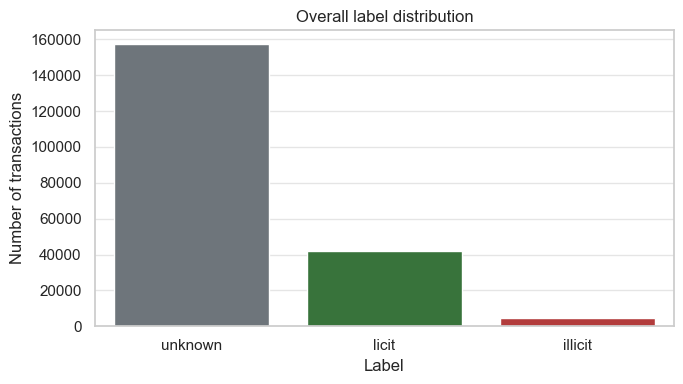

In [155]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=label_counts,
    x="label",
    y="count",
    order=label_order,
    palette=label_palette,
    hue="label",
    legend=False,
    ax=ax,
)
ax.set_title("Overall label distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Number of transactions")
fig.tight_layout()
plt.show()

## Known-label class imbalance

For supervised binary classification, remove `unknown` rows and inspect the balance between licit and illicit transactions.

### Known-label counts and shares

The illicit class is expected to be the minority class. This has direct implications for model metrics and validation.

In [156]:
known_df = df[df["label"].isin(known_label_order)].copy()

known_counts = (
    known_df["label"]
    .value_counts()
    .reindex(known_label_order, fill_value=0)
    .rename_axis("label")
    .reset_index(name="count")
)

known_counts["share_pct"] = (known_counts["count"] / len(known_df) * 100).round(2)
known_counts

,label,count,share_pct
0,licit,42019,90.24
1,illicit,4545,9.76


### Class imbalance ratio

This ratio expresses how many licit transactions there are for each illicit transaction in the supervised subset.

In [157]:
known_count_lookup = known_counts.set_index("label")["count"]
licit_to_illicit_ratio = known_count_lookup["licit"] / known_count_lookup["illicit"]

pd.DataFrame({
    "metric": ["known_rows", "licit_to_illicit_ratio"],
    "value": [len(known_df), round(licit_to_illicit_ratio, 2)],
})

,metric,value
0,known_rows,46564.00
1,licit_to_illicit_ratio,9.25


### Known-label chart

The supervised subset is strongly imbalanced, so later modeling should avoid relying on accuracy alone.

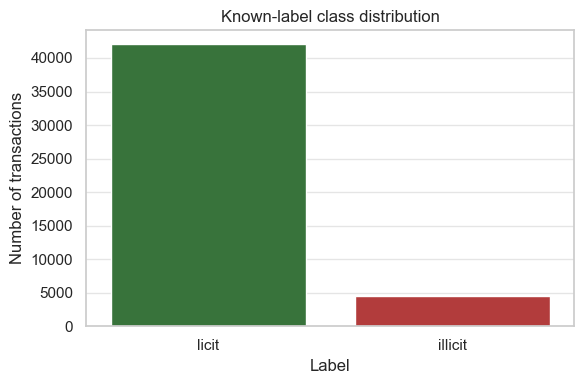

In [158]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=known_counts,
    x="label",
    y="count",
    order=known_label_order,
    palette=label_palette,
    hue="label",
    legend=False,
    ax=ax,
)
ax.set_title("Known-label class distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Number of transactions")
fig.tight_layout()
plt.show()

### Modeling note

The supervised subset is imbalanced: illicit transactions are a minority class. For modeling, accuracy should not be the main metric; precision, recall, F1-score, and PR-AUC are more appropriate.

## Labels over time

The dataset has an explicit temporal structure. Analyzing labels by `time_step` helps reveal whether class availability and class proportions are stable over time.

### Label counts by time step

Group transactions by time step and readable label.

In [159]:
labels_by_time = (
    df.groupby(["time_step", "label"])
    .size()
    .reset_index(name="count")
)

label_time_pivot = (
    labels_by_time
    .pivot(index="time_step", columns="label", values="count")
    .reindex(columns=label_order, fill_value=0)
    .fillna(0)
    .astype(int)
)

label_time_pivot["total"] = label_time_pivot[label_order].sum(axis=1)
label_time_pivot.head()

label,unknown,licit,illicit,total
time_step,,,,
1,5733,2130,17,7880
2,3427,1099,18,4544
3,5342,1268,11,6621
4,4253,1410,30,5693
5,4921,1874,8,6803


### Label counts over time

This line chart shows how the number of transactions in each label category changes across time steps.

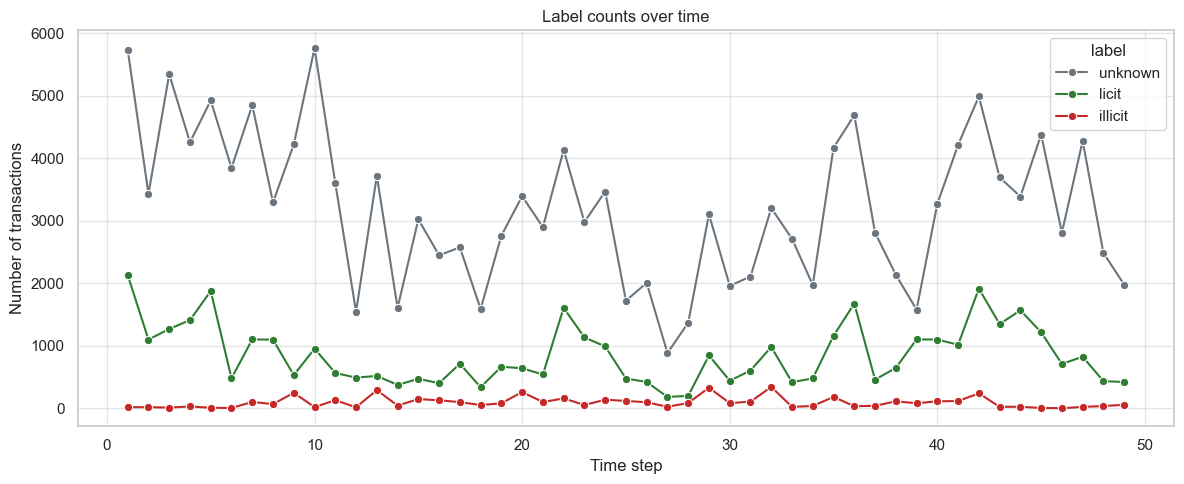

In [160]:
label_time_long = (
    label_time_pivot
    .reset_index()
    .melt(id_vars="time_step", value_vars=label_order, var_name="label", value_name="count")
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=label_time_long,
    x="time_step",
    y="count",
    hue="label",
    hue_order=label_order,
    palette=label_palette,
    marker="o",
    ax=ax,
)
ax.set_title("Label counts over time")
ax.set_xlabel("Time step")
ax.set_ylabel("Number of transactions")
fig.tight_layout()
plt.show()

### Label shares over time

Counts can be affected by changing transaction volume. Label shares show the composition of each time step.

In [161]:
label_share_by_time = (
    label_time_pivot[label_order]
    .div(label_time_pivot["total"], axis=0)
    .mul(100)
)

label_share_by_time.head().round(2)

label,unknown,licit,illicit
time_step,,,
1,72.75,27.03,0.22
2,75.42,24.19,0.40
3,80.68,19.15,0.17
4,74.71,24.77,0.53
5,72.34,27.55,0.12


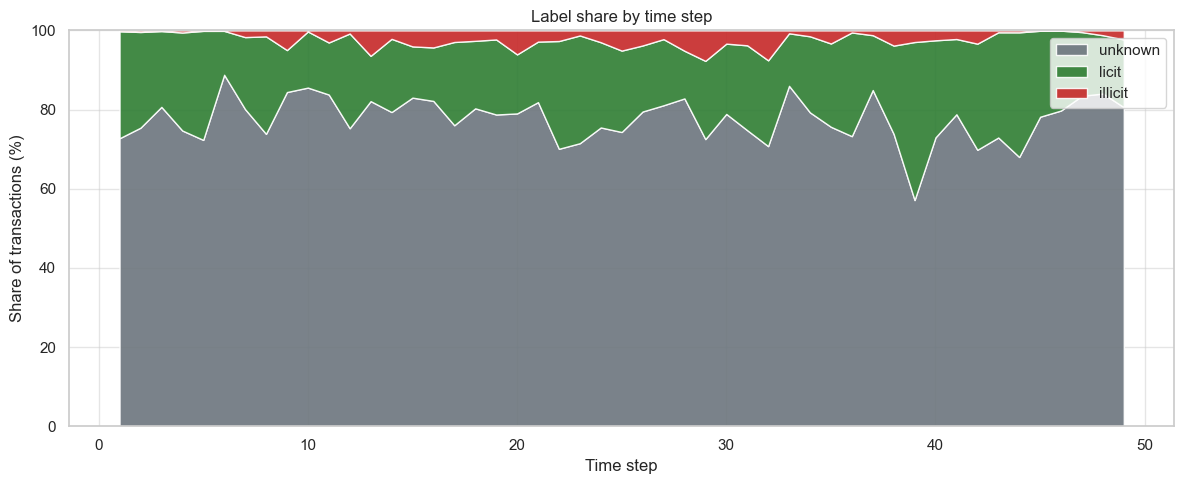

In [162]:
share_plot = label_share_by_time.reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(
    share_plot["time_step"],
    share_plot["unknown"],
    share_plot["licit"],
    share_plot["illicit"],
    labels=label_order,
    colors=[label_palette[label] for label in label_order],
    alpha=0.9,
)
ax.set_title("Label share by time step")
ax.set_xlabel("Time step")
ax.set_ylabel("Share of transactions (%)")
ax.set_ylim(0, 100)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## Known vs unknown labels over time

Before modeling, it is useful to see how many transactions per time step have usable supervised labels.

In [163]:
df["label_known_status"] = np.where(df["label"] == "unknown", "unknown", "known")

known_status_by_time = (
    df.groupby(["time_step", "label_known_status"])
    .size()
    .reset_index(name="count")
)

known_status_pivot = (
    known_status_by_time
    .pivot(index="time_step", columns="label_known_status", values="count")
    .reindex(columns=["known", "unknown"], fill_value=0)
    .fillna(0)
    .astype(int)
)

known_status_pivot["total"] = known_status_pivot[["known", "unknown"]].sum(axis=1)
known_status_pivot["known_share_pct"] = (
        known_status_pivot["known"] / known_status_pivot["total"] * 100
).round(2)

known_status_pivot.head()

label_known_status,known,unknown,total,known_share_pct
time_step,,,,
1,2147,5733,7880,27.25
2,1117,3427,4544,24.58
3,1279,5342,6621,19.32
4,1440,4253,5693,25.29
5,1882,4921,6803,27.66


### Known vs unknown counts

This plot separates transactions with usable supervised labels from unlabeled transactions.

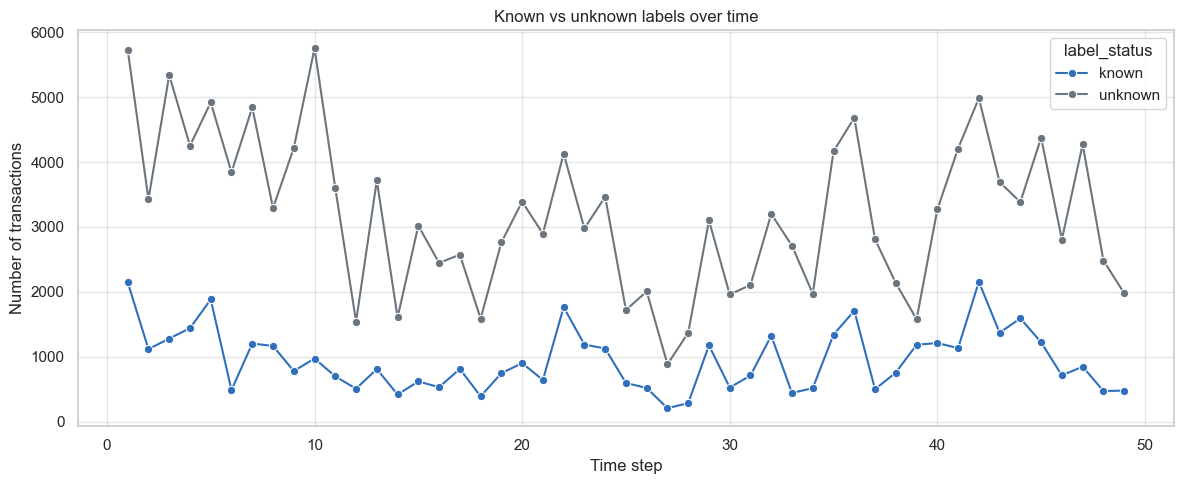

In [164]:
known_status_long = (
    known_status_pivot
    .reset_index()
    .melt(id_vars="time_step", value_vars=["known", "unknown"], var_name="label_status", value_name="count")
)

status_palette = {"known": label_palette["known"], "unknown": label_palette["unknown"]}

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=known_status_long,
    x="time_step",
    y="count",
    hue="label_status",
    hue_order=["known", "unknown"],
    palette=status_palette,
    marker="o",
    ax=ax,
)
ax.set_title("Known vs unknown labels over time")
ax.set_xlabel("Time step")
ax.set_ylabel("Number of transactions")
fig.tight_layout()
plt.show()

### Known-label share over time

The known-label share indicates how much supervised signal is available in each time step.

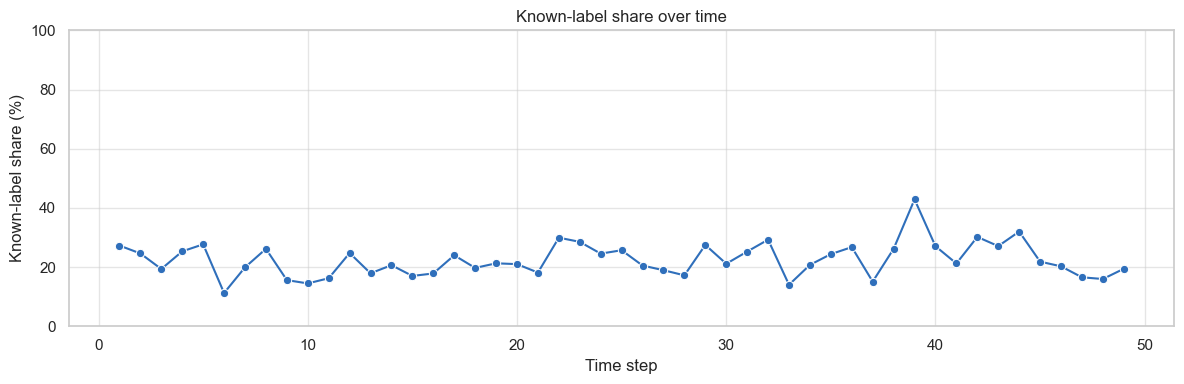

In [165]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(
    data=known_status_pivot.reset_index(),
    x="time_step",
    y="known_share_pct",
    marker="o",
    color=label_palette["known"],
    ax=ax,
)
ax.set_title("Known-label share over time")
ax.set_xlabel("Time step")
ax.set_ylabel("Known-label share (%)")
ax.set_ylim(0, 100)
fig.tight_layout()
plt.show()

## Illicit share among known labels

For the supervised subset, inspect how the illicit rate changes over time. This is important because a random train-test split can hide temporal shifts.

In [166]:
known_by_time = (
    known_df.groupby(["time_step", "label"])
    .size()
    .unstack(fill_value=0)
)

for label in known_label_order:
    if label not in known_by_time.columns:
        known_by_time[label] = 0

known_by_time = known_by_time[known_label_order]
known_by_time["known_total"] = known_by_time[known_label_order].sum(axis=1)
known_by_time["illicit_share_pct"] = np.where(
    known_by_time["known_total"] > 0,
    known_by_time["illicit"] / known_by_time["known_total"] * 100,
    np.nan,
)

known_by_time.head().round(2)

label,licit,illicit,known_total,illicit_share_pct
time_step,,,,
1,2130,17,2147,0.79
2,1099,18,1117,1.61
3,1268,11,1279,0.86
4,1410,30,1440,2.08
5,1874,8,1882,0.43


### Illicit share chart

Large variation in this line suggests that future model validation should respect time order.

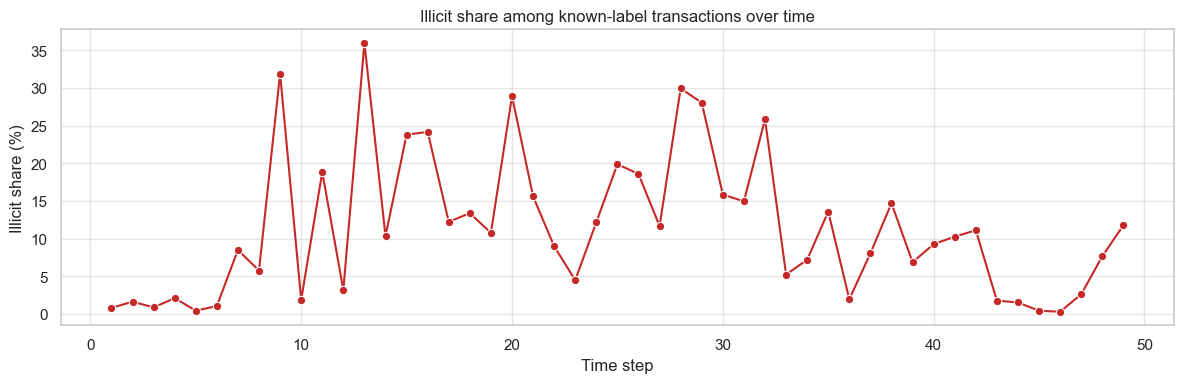

In [167]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(
    data=known_by_time.reset_index(),
    x="time_step",
    y="illicit_share_pct",
    marker="o",
    color=label_palette["illicit"],
    ax=ax,
)
ax.set_title("Illicit share among known-label transactions over time")
ax.set_xlabel("Time step")
ax.set_ylabel("Illicit share (%)")
fig.tight_layout()
plt.show()

## Temporal coverage summary

Summarize basic time coverage for all transactions and for the supervised subset. This helps check whether known labels are concentrated in only a few time steps.

In [168]:
temporal_coverage = pd.DataFrame({
    "metric": [
        "all_time_step_min",
        "all_time_step_max",
        "known_time_step_min",
        "known_time_step_max",
        "n_time_steps_total",
        "n_time_steps_with_known_labels",
        "n_time_steps_with_illicit_labels",
    ],
    "value": [
        int(df["time_step"].min()),
        int(df["time_step"].max()),
        int(known_df["time_step"].min()),
        int(known_df["time_step"].max()),
        int(df["time_step"].nunique()),
        int(known_df["time_step"].nunique()),
        int(known_df.loc[known_df["label"] == "illicit", "time_step"].nunique()),
    ],
})

temporal_coverage

,metric,value
0,all_time_step_min,1
1,all_time_step_max,49
2,known_time_step_min,1
3,known_time_step_max,49
4,n_time_steps_total,49
5,n_time_steps_with_known_labels,49
6,n_time_steps_with_illicit_labels,49


## Suggested chronological split

A chronological split avoids training on future transactions. The exact boundaries can be adjusted later, but this split is a practical starting point for baseline modeling.

### Split definition

Use time steps `1-34` for training, `35-42` for validation, and `43-49` for testing.

In [169]:
def split_period(time_step):
    if time_step <= 34:
        return "train"
    if time_step <= 42:
        return "validation"
    return "test"


split_order = ["train", "validation", "test"]

df["split"] = df["time_step"].apply(split_period)
known_df["split"] = known_df["time_step"].apply(split_period)

df[["time_step", "split"]].drop_duplicates().sort_values("time_step").head(12)

,time_step,split
0,1,train
7880,2,train
12424,3,train
19045,4,train
24738,5,train
31541,6,train
35869,7,train
41917,8,train
46374,9,train
51370,10,train


### Split summary for known labels

Check whether each split contains both supervised classes and how the illicit share changes across splits.

In [170]:
split_summary = (
    known_df.groupby(["split", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(split_order)
)

for label in known_label_order:
    if label not in split_summary.columns:
        split_summary[label] = 0

split_summary = split_summary[known_label_order]
split_summary["total"] = split_summary[known_label_order].sum(axis=1)
split_summary["illicit_share_pct"] = (
        split_summary["illicit"] / split_summary["total"] * 100
).round(2)

split_summary

label,licit,illicit,total,illicit_share_pct
split,,,,
train,26432,3462,29894,11.58
validation,9069,914,9983,9.16
test,6518,169,6687,2.53


### Split boundaries on illicit share

Plot the proposed split boundaries over the illicit-share time series.

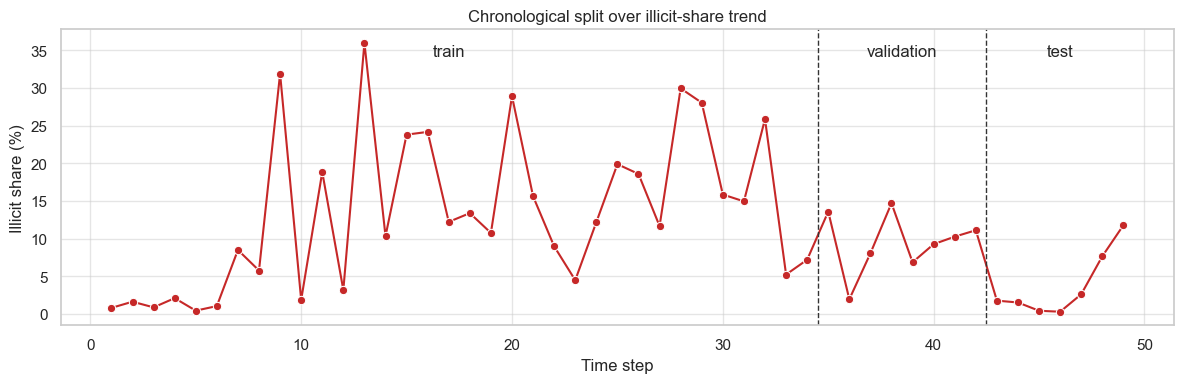

In [171]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(
    data=known_by_time.reset_index(),
    x="time_step",
    y="illicit_share_pct",
    marker="o",
    color=label_palette["illicit"],
    ax=ax,
)
ax.axvline(34.5, color="#333333", linestyle="--", linewidth=1)
ax.axvline(42.5, color="#333333", linestyle="--", linewidth=1)
ax.text(17, ax.get_ylim()[1] * 0.95, "train", ha="center", va="top")
ax.text(38.5, ax.get_ylim()[1] * 0.95, "validation", ha="center", va="top")
ax.text(46, ax.get_ylim()[1] * 0.95, "test", ha="center", va="top")
ax.set_title("Chronological split over illicit-share trend")
ax.set_xlabel("Time step")
ax.set_ylabel("Illicit share (%)")
fig.tight_layout()
plt.show()

## Save key output

Save one compact JSON report with the key label, time, imbalance, and chronological split information. The plots remain in the notebook output and do not need separate files.

In [172]:
analysis_summary = {
    "n_transactions": int(len(df)),
    "n_known_label_transactions": int(len(known_df)),
    "n_unknown_label_transactions": int((df["label"] == "unknown").sum()),
    "known_label_share_pct": round(float(len(known_df) / len(df) * 100), 2),
    "licit_transactions": int(known_count_lookup["licit"]),
    "illicit_transactions": int(known_count_lookup["illicit"]),
    "licit_to_illicit_ratio": round(float(licit_to_illicit_ratio), 2),
    "time_step_min": int(df["time_step"].min()),
    "time_step_max": int(df["time_step"].max()),
    "split_summary": split_summary.reset_index().to_dict(orient="records"),
}

summary_path = OUTPUT_DIR / "01_labels_and_time_eda_summary.json"
with summary_path.open("w") as f:
    json.dump(analysis_summary, f, indent=2)

{
    "summary_path": summary_path,
    "summary": analysis_summary,
}

{'summary_path': PosixPath('../outputs/01_labels_and_time_eda_summary.json'),
 'summary': {'n_transactions': 203769,
  'n_known_label_transactions': 46564,
  'n_unknown_label_transactions': 157205,
  'known_label_share_pct': 22.85,
  'licit_transactions': 42019,
  'illicit_transactions': 4545,
  'licit_to_illicit_ratio': 9.25,
  'time_step_min': 1,
  'time_step_max': 49,
  'split_summary': [{'split': 'train',
    'licit': 26432,
    'illicit': 3462,
    'total': 29894,
    'illicit_share_pct': 11.58},
   {'split': 'validation',
    'licit': 9069,
    'illicit': 914,
    'total': 9983,
    'illicit_share_pct': 9.16},
   {'split': 'test',
    'licit': 6518,
    'illicit': 169,
    'total': 6687,
    'illicit_share_pct': 2.53}]}}

In [173]:
[summary_path.name]

['01_labels_and_time_eda_summary.json']

## Conclusions

- Most transactions are labeled as `unknown`, so they should not be used as a supervised class.
- Among known labels, illicit transactions are the minority class.
- Label availability and class proportions vary across time steps.
- Future modeling should use metrics robust to class imbalance, especially precision, recall, F1-score, and PR-AUC.
- A chronological split is preferable to a purely random split because the dataset has an explicit temporal structure.